#  Anime Face Generation: VAE vs DCGAN
### Πανεπιστήμιο Θεσσαλίας — ΠΜΣ Εφαρμοσμένα Μαθηματικά & Μηχανική Μάθηση
### Μάθημα: Μηχανική Μάθηση - Βαθιά Μάθηση

---
**Dataset:** [Anime Face Dataset](https://www.kaggle.com/datasets/splcher/animefacedataset) (~63K εικόνες 64×64)  
**Μοντέλα:** Variational Autoencoder (VAE) vs Deep Convolutional GAN (DCGAN)  
**Στόχος:** Παραγωγή συνθετικών προσώπων anime και σύγκριση των δύο προσεγγίσεων

>  **ΣΗΜΑΝΤΙΚΟ:** Πριν τρέξετε, πηγαίνετε: `Runtime → Change runtime type → T4 GPU`


##  Cell 1: Εγκατάσταση & Imports

In [1]:
!pip install kagglehub --quiet

import os, random, time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image
from scipy import linalg

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device: {DEVICE}")
print(f" PyTorch: {torch.__version__}")
print(f" CUDA available: {torch.cuda.is_available()}")



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\xaris\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


 Device: cpu
 PyTorch: 2.11.0+cpu
 CUDA available: False


##  Cell 2: Κατέβασμα Dataset (Kaggle)

In [2]:
import kagglehub

# Κατεβάζει αυτόματα το Anime Face Dataset
path = kagglehub.dataset_download("splcher/animefacedataset")
print(f" Dataset path: {path}")

# Βρίσκουμε τον φάκελο με τις εικόνες
IMAGE_DIR = None
for root, dirs, files in os.walk(path):
    jpg_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(jpg_files) > 100:
        IMAGE_DIR = root
        print(f" Βρέθηκαν {len(jpg_files):,} εικόνες στο: {root}")
        break

assert IMAGE_DIR is not None, " Δεν βρέθηκαν εικόνες!"
print(" Dataset έτοιμο!")


C:\Users\xaris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 395M/395M [02:03<00:00, 3.35MB/s] 

Extracting files...


 Dataset path: C:\Users\xaris\.cache\kagglehub\datasets\splcher\animefacedataset\versions\3
 Βρέθηκαν 63,565 εικόνες στο: C:\Users\xaris\.cache\kagglehub\datasets\splcher\animefacedataset\versions\3\images
 Dataset έτοιμο!


##  Cell 3: EDA — Διερευνητική Ανάλυση Δεδομένων


 ΣΤΑΤΙΣΤΙΚΑ DATASET
────────────────────────────────────────
  Συνολικές εικόνες : 63,565


Ανάλυση εικόνων: 100%|██████████| 500/500 [00:00<00:00, 1259.54it/s]


  Μέση ανάλυση      : 90 x 90
  Εύρος πλάτους     : 39 - 164
  Μέση τιμή R/G/B   : 0.686 / 0.590 / 0.574


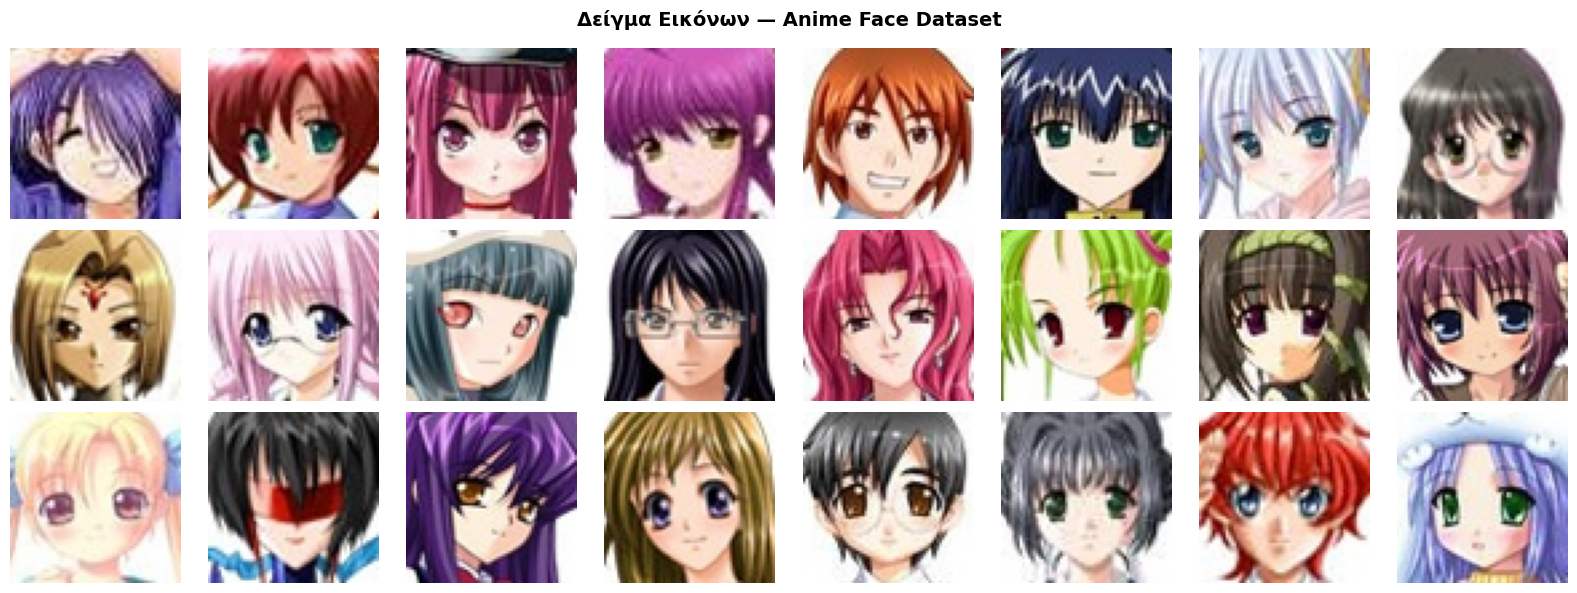

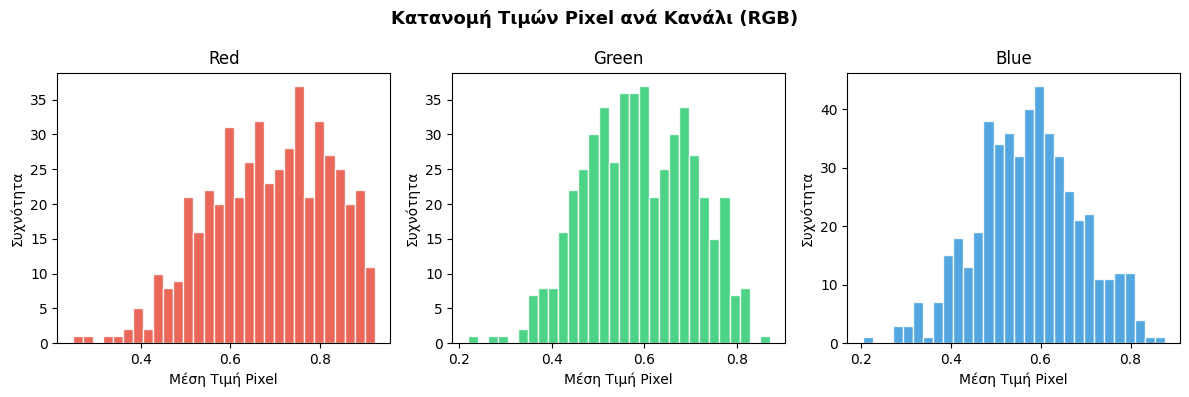

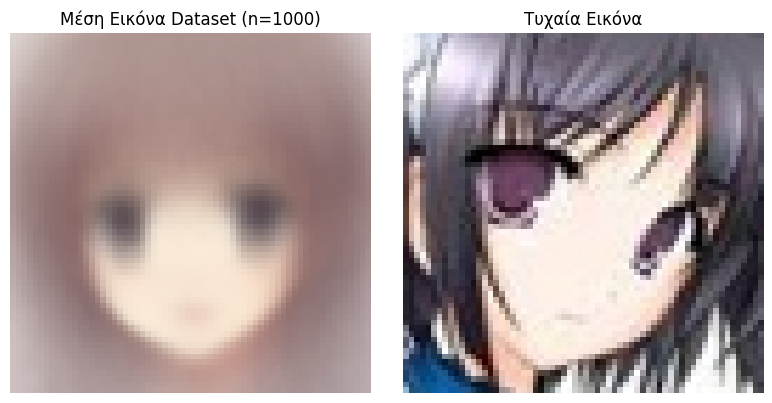

 EDA ολοκληρώθηκε!


In [3]:
all_images = [f for f in os.listdir(IMAGE_DIR)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
print(f"\n ΣΤΑΤΙΣΤΙΚΑ DATASET")
print(f"{'─'*40}")
print(f"  Συνολικές εικόνες : {len(all_images):,}")

# Δειγματοληψία 500 εικόνων για ανάλυση
sample_files = random.sample(all_images, min(500, len(all_images)))
widths, heights = [], []
means_r, means_g, means_b = [], [], []

for fname in tqdm(sample_files, desc="Ανάλυση εικόνων"):
    img = Image.open(os.path.join(IMAGE_DIR, fname)).convert('RGB')
    w, h = img.size
    widths.append(w); heights.append(h)
    arr = np.array(img) / 255.0
    means_r.append(arr[:,:,0].mean())
    means_g.append(arr[:,:,1].mean())
    means_b.append(arr[:,:,2].mean())

print(f"  Μέση ανάλυση      : {int(np.mean(widths))} x {int(np.mean(heights))}")
print(f"  Εύρος πλάτους     : {min(widths)} - {max(widths)}")
print(f"  Μέση τιμή R/G/B   : {np.mean(means_r):.3f} / {np.mean(means_g):.3f} / {np.mean(means_b):.3f}")

# ── Οπτικοποίηση 1: Δείγμα εικόνων ──
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle('Δείγμα Εικόνων — Anime Face Dataset', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    img = Image.open(os.path.join(IMAGE_DIR, all_images[i])).convert('RGB').resize((64,64))
    ax.imshow(img); ax.axis('off')
plt.tight_layout()
plt.savefig('eda_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Οπτικοποίηση 2: Κατανομές pixel ──
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Κατανομή Τιμών Pixel ανά Κανάλι (RGB)', fontsize=13, fontweight='bold')
for ax, ch, col, lbl in zip(axes,
                              [means_r, means_g, means_b],
                              ['#e74c3c','#2ecc71','#3498db'],
                              ['Red','Green','Blue']):
    ax.hist(ch, bins=30, color=col, alpha=0.85, edgecolor='white')
    ax.set_title(lbl); ax.set_xlabel('Μέση Τιμή Pixel'); ax.set_ylabel('Συχνότητα')
plt.tight_layout()
plt.savefig('eda_pixel_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Οπτικοποίηση 3: Μέση εικόνα ──
sample_arrays = []
for fname in random.sample(all_images, 1000):
    img = Image.open(os.path.join(IMAGE_DIR, fname)).convert('RGB').resize((64,64))
    sample_arrays.append(np.array(img))
mean_image = np.mean(sample_arrays, axis=0).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mean_image); axes[0].set_title('Μέση Εικόνα Dataset (n=1000)'); axes[0].axis('off')
axes[1].imshow(sample_arrays[0]); axes[1].set_title('Τυχαία Εικόνα'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('eda_mean_image.png', dpi=150, bbox_inches='tight')
plt.show()

print(" EDA ολοκληρώθηκε!")


## ️ Cell 4: Dataset & DataLoader

In [4]:
IMG_SIZE    = 64
BATCH_SIZE  = 128
NUM_WORKERS = 2
MAX_SAMPLES = 20000   # Αλλάξτε σε None για το πλήρες dataset

class AnimeFaceDataset(Dataset):
    def __init__(self, image_dir, transform=None, max_samples=None):
        self.image_dir = image_dir
        self.transform = transform
        self.files = [f for f in os.listdir(image_dir)
                      if f.lower().endswith(('.jpg','.jpeg','.png'))]
        if max_samples:
            self.files = self.files[:max_samples]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.image_dir, self.files[idx])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])   # [-1, 1]
])

dataset = AnimeFaceDataset(IMAGE_DIR, transform=transform, max_samples=MAX_SAMPLES)

val_size   = int(0.1 * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f" Train: {len(train_dataset):,} | Val: {len(val_dataset):,}")
print(f" Batches — Train: {len(train_loader)} | Val: {len(val_loader)}")
print(" DataLoaders έτοιμα!")


 Train: 18,000 | Val: 2,000
 Batches — Train: 141 | Val: 16
 DataLoaders έτοιμα!


##  Cell 5: VAE Αρχιτεκτονική

> Ένας **Variational Autoencoder** εκπαιδεύεται να συμπιέζει εικόνες σε ένα πιθανοτικό latent space (μ, σ) και να τις ανακατασκευάζει. Η loss αποτελείται από **Reconstruction Loss** (MSE) + **KL Divergence**.

In [5]:
LATENT_DIM = 256

class VAEEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,   64,  4, 2, 1),                           nn.LeakyReLU(0.2, True),
            nn.Conv2d(64,  128, 4, 2, 1), nn.BatchNorm2d(128),     nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256),     nn.LeakyReLU(0.2, True),
            nn.Conv2d(256, 512, 4, 2, 1), nn.BatchNorm2d(512),     nn.LeakyReLU(0.2, True),
        )  # 64x64 → 4x4
        self.fc_mu  = nn.Linear(512*4*4, latent_dim)
        self.fc_log = nn.Linear(512*4*4, latent_dim)

    def forward(self, x):
        x = self.conv(x).view(x.size(0), -1)
        return self.fc_mu(x), self.fc_log(x)


class VAEDecoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512*4*4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128,  64, 4, 2, 1), nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d( 64,   3, 4, 2, 1), nn.Tanh()
        )  # 4x4 → 64x64

    def forward(self, z):
        return self.deconv(self.fc(z).view(z.size(0), 512, 4, 4))


class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = VAEDecoder(latent_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        return self.decoder(z), mu, log_var

    def sample(self, n, device):
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decoder(z)


def vae_loss(recon_x, x, mu, log_var, beta=1.5):
    recon = F.mse_loss(recon_x, x, reduction='sum') / x.size(0)
    kld   = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon + beta * kld, recon.item(), kld.item()


# Έλεγχος
_vae = VAE().to(DEVICE)
_x   = torch.randn(4, 3, 64, 64, device=DEVICE)
_out, _mu, _lv = _vae(_x)
print(f" VAE: input {_x.shape} → output {_out.shape}")
print(f"   Παράμετροι: {sum(p.numel() for p in _vae.parameters()):,}")
del _vae, _x, _out, _mu, _lv


 VAE: input torch.Size([4, 3, 64, 64]) → output torch.Size([4, 3, 64, 64])
   Παράμετροι: 11,815,427


## ️ Cell 6: DCGAN Αρχιτεκτονική

> Το **DCGAN** αποτελείται από έναν **Generator** (παράγει εικόνες από random noise) και έναν **Discriminator** (κρίνει αν μια εικόνα είναι πραγματική ή ψεύτικη). Εκπαιδεύονται σε adversarial παιχνίδι.

In [7]:
NZ  = 100   # Διάσταση latent noise
NGF = 64    # Generator feature maps base
NDF = 64    # Discriminator feature maps base

def weights_init(m):
    "Αρχικοποίηση βαρών σύμφωνα με το DCGAN paper (Radford et al., 2015)"
    cn = m.__class__.__name__
    if 'Conv' in cn:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in cn:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(NZ,    NGF*8, 4, 1, 0, bias=False), nn.BatchNorm2d(NGF*8), nn.ReLU(True),  # 4x4
            nn.ConvTranspose2d(NGF*8, NGF*4, 4, 2, 1, bias=False), nn.BatchNorm2d(NGF*4), nn.ReLU(True),  # 8x8
            nn.ConvTranspose2d(NGF*4, NGF*2, 4, 2, 1, bias=False), nn.BatchNorm2d(NGF*2), nn.ReLU(True),  # 16x16
            nn.ConvTranspose2d(NGF*2, NGF,   4, 2, 1, bias=False), nn.BatchNorm2d(NGF),   nn.ReLU(True),  # 32x32
            nn.ConvTranspose2d(NGF,   3,     4, 2, 1, bias=False), nn.Tanh()                               # 64x64
        )
    def forward(self, z): return self.main(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3,     NDF,   4, 2, 1, bias=False),                          nn.LeakyReLU(0.2, True),   # 32x32
            nn.Conv2d(NDF,   NDF*2, 4, 2, 1, bias=False), nn.BatchNorm2d(NDF*2),  nn.LeakyReLU(0.2, True),   # 16x16
            nn.Conv2d(NDF*2, NDF*4, 4, 2, 1, bias=False), nn.BatchNorm2d(NDF*4),  nn.LeakyReLU(0.2, True),   # 8x8
            nn.Conv2d(NDF*4, NDF*8, 4, 2, 1, bias=False), nn.BatchNorm2d(NDF*8),  nn.LeakyReLU(0.2, True),   # 4x4
            nn.Conv2d(NDF*8, 1,     4, 1, 0, bias=False), nn.Sigmoid()                                        # 1x1
        )
    def forward(self, x): return self.main(x).view(-1)


# Έλεγχος
_G = Generator().to(DEVICE); _D = Discriminator().to(DEVICE)
_z = torch.randn(4, NZ, 1, 1, device=DEVICE)
_f = _G(_z)
print(f" Generator  : z {_z.shape} → fake {_f.shape}")
print(f"   G παράμετροι: {sum(p.numel() for p in _G.parameters()):,}")
print(f"   D παράμετροι: {sum(p.numel() for p in _D.parameters()):,}")
del _G, _D, _z, _f


 Generator  : z torch.Size([4, 100, 1, 1]) → fake torch.Size([4, 3, 64, 64])
   G παράμετροι: 3,576,704
   D παράμετροι: 2,765,568


##  Cell 7: Εκπαίδευση VAE

In [ ]:
VAE_EPOCHS = 30
VAE_LR     = 1e-3
BETA       = 1.5    # β-VAE: βάρος KL term

vae           = VAE(LATENT_DIM).to(DEVICE)
vae_optimizer = optim.Adam(vae.parameters(), lr=VAE_LR)
vae_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    vae_optimizer, 'min', patience=3, factor=0.5)

vae_train_losses, vae_val_losses = [], []
vae_recon_losses, vae_kld_losses = [], []
best_vae_loss = float('inf')

print(f" Εκπαίδευση VAE ({VAE_EPOCHS} epochs, β={BETA})...")
print(f"{'─'*65}")
print(f"  {'Epoch':>6} | {'Train':>10} | {'Val':>10} | {'Recon':>10} | {'KLD':>8}")
print(f"{'─'*65}")

for epoch in range(1, VAE_EPOCHS + 1):
    # ── Train ──
    vae.train()
    t_loss = t_recon = t_kld = 0.0
    for batch in train_loader:
        x = batch.to(DEVICE)
        vae_optimizer.zero_grad()
        recon, mu, log_var = vae(x)
        loss, rl, kl = vae_loss(recon, x, mu, log_var, BETA)
        loss.backward()
        nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
        vae_optimizer.step()
        t_loss += loss.item(); t_recon += rl; t_kld += kl

    # ── Validation ──
    vae.eval()
    v_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x = batch.to(DEVICE)
            recon, mu, log_var = vae(x)
            loss, _, _ = vae_loss(recon, x, mu, log_var, BETA)
            v_loss += loss.item()

    avg_train = t_loss  / len(train_loader)
    avg_val   = v_loss  / len(val_loader)
    avg_recon = t_recon / len(train_loader)
    avg_kld   = t_kld   / len(train_loader)

    vae_train_losses.append(avg_train)
    vae_val_losses.append(avg_val)
    vae_recon_losses.append(avg_recon)
    vae_kld_losses.append(avg_kld)
    vae_scheduler.step(avg_val)

    if avg_val < best_vae_loss:
        best_vae_loss = avg_val
        torch.save(vae.state_dict(), 'best_vae.pth')
        marker = " "
    else:
        marker = ""

    if epoch % 5 == 0 or epoch == 1:
        print(f"  {epoch:6d} | {avg_train:10.2f} | {avg_val:10.2f} | {avg_recon:10.2f} | {avg_kld:8.4f}{marker}")

    # Αποθήκευση εικόνων κάθε 10 epochs
    if epoch % 10 == 0:
        vae.eval()
        with torch.no_grad():
            s = vae.sample(64, DEVICE)
        save_image((s+1)/2, f'vae_epoch_{epoch:03d}.png', nrow=8)

print(f"{'─'*65}")
print(f"\n Καλύτερο VAE val loss: {best_vae_loss:.4f}")
vae.load_state_dict(torch.load('best_vae.pth'))
print(" Φορτώθηκαν τα καλύτερα βάρη VAE!")


 Εκπαίδευση VAE (30 epochs, β=1.5)...
─────────────────────────────────────────────────────────────────
   Epoch |      Train |        Val |      Recon |      KLD
─────────────────────────────────────────────────────────────────


C:\Users\xaris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## ️ Cell 8: Εκπαίδευση DCGAN

In [ ]:
GAN_EPOCHS  = 50
LR_G = LR_D = 2e-4
BETA1        = 0.5
REAL_LABEL   = 0.9    # Label smoothing για σταθερότητα
FAKE_LABEL   = 0.0

netG = Generator().to(DEVICE).apply(weights_init)
netD = Discriminator().to(DEVICE).apply(weights_init)

criterion  = nn.BCELoss()
optimizerG = optim.Adam(netG.parameters(), lr=LR_G, betas=(BETA1, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=LR_D, betas=(BETA1, 0.999))

fixed_noise = torch.randn(64, NZ, 1, 1, device=DEVICE)

G_losses, D_losses, D_x_hist, D_G_z_hist = [], [], [], []

print(f" Εκπαίδευση DCGAN ({GAN_EPOCHS} epochs)...")
print(f"{'─'*70}")
print(f"  {'Epoch':>6} | {'Loss_D':>8} | {'Loss_G':>8} | {'D(x)':>8} | {'D(G(z))':>10}")
print(f"{'─'*70}")

for epoch in range(1, GAN_EPOCHS + 1):
    netG.train(); netD.train()
    e_G = e_D = e_Dx = e_DGz = 0.0

    for real in train_loader:
        real   = real.to(DEVICE)
        b_size = real.size(0)

        # ── Train Discriminator ──
        netD.zero_grad()
        lbl = torch.full((b_size,), REAL_LABEL, device=DEVICE)
        out_r = netD(real + 0.05 * torch.randn_like(real))  # Instance noise
        errD_r = criterion(out_r, lbl); errD_r.backward()
        D_x = out_r.mean().item()

        noise = torch.randn(b_size, NZ, 1, 1, device=DEVICE)
        fake  = netG(noise)
        lbl.fill_(FAKE_LABEL)
        errD_f = criterion(netD(fake.detach()), lbl); errD_f.backward()
        optimizerD.step()

        # ── Train Generator ──
        netG.zero_grad()
        lbl.fill_(REAL_LABEL)
        errG = criterion(netD(fake), lbl); errG.backward()
        D_Gz = netD(fake).mean().item()
        optimizerG.step()

        e_G += errG.item(); e_D += (errD_r + errD_f).item()
        e_Dx += D_x; e_DGz += D_Gz

    n = len(train_loader)
    G_losses.append(e_G/n); D_losses.append(e_D/n)
    D_x_hist.append(e_Dx/n); D_G_z_hist.append(e_DGz/n)

    if epoch % 5 == 0 or epoch == 1:
        print(f"  {epoch:6d} | {e_D/n:8.4f} | {e_G/n:8.4f} | {e_Dx/n:8.4f} | {e_DGz/n:10.4f}")

    if epoch % 10 == 0:
        torch.save(netG.state_dict(), f'dcgan_G_epoch_{epoch:03d}.pth')
        with torch.no_grad():
            imgs = netG(fixed_noise)
        save_image((imgs+1)/2, f'dcgan_epoch_{epoch:03d}.png', nrow=8)

torch.save(netG.state_dict(), 'best_dcgan_G.pth')
print(f"{'─'*70}")
print(" DCGAN εκπαιδεύτηκε! Βάρη αποθηκεύτηκαν.")


##  Cell 9: Καμπύλες Εκπαίδευσης

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Καμπύλες Εκπαίδευσης — VAE & DCGAN', fontsize=15, fontweight='bold')

# VAE: Train vs Val Loss
axes[0,0].plot(vae_train_losses, label='Train', color='#3498db', lw=2)
axes[0,0].plot(vae_val_losses,   label='Val',   color='#e74c3c', lw=2, ls='--')
axes[0,0].set_title('VAE: Train vs Validation Loss')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Total Loss')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# VAE: Recon vs KLD
axes[0,1].plot(vae_recon_losses, label='Reconstruction Loss', color='#2ecc71', lw=2)
axes[0,1].plot(vae_kld_losses,   label='KL Divergence',       color='#9b59b6', lw=2)
axes[0,1].set_title('VAE: Ανάλυση Loss (Recon + KLD)')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# DCGAN: G & D Losses
axes[1,0].plot(G_losses, label='Generator',     color='#e67e22', lw=2)
axes[1,0].plot(D_losses, label='Discriminator', color='#1abc9c', lw=2)
axes[1,0].set_title('DCGAN: Generator vs Discriminator Loss')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('BCE Loss')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# DCGAN: Scores
axes[1,1].plot(D_x_hist,   label='D(x) — Real',  color='#2980b9', lw=2)
axes[1,1].plot(D_G_z_hist, label='D(G(z)) — Fake',color='#c0392b', lw=2)
axes[1,1].axhline(0.5, color='gray', ls=':', alpha=0.7, label='Nash Eq. (0.5)')
axes[1,1].set_title('DCGAN: Βαθμολογίες Discriminator')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Score')
axes[1,1].set_ylim(0, 1); axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Καμπύλες αποθηκεύτηκαν → training_curves.png")


## ️ Cell 10: Ποιοτική Σύγκριση (Qualitative)

In [ ]:
vae.eval(); netG.eval()

with torch.no_grad():
    vae_samples = (vae.sample(16, DEVICE) + 1) / 2
    gan_samples = (netG(torch.randn(16, NZ, 1, 1, device=DEVICE)) + 1) / 2
    real_batch  = next(iter(val_loader))[:16].to(DEVICE)
    vae_recon, _, _ = vae(real_batch)
    vae_recon   = (vae_recon   + 1) / 2
    real_display = (real_batch + 1) / 2

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Σύγκριση: Real vs VAE vs DCGAN', fontsize=16, fontweight='bold')

def show_grid(ax, imgs, title, color='black'):
    grid = make_grid(imgs.cpu(), nrow=8, padding=2, normalize=False)
    ax.imshow(grid.permute(1,2,0).clamp(0,1))
    ax.set_title(title, fontsize=13, color=color, fontweight='bold')
    ax.axis('off')

ax1 = fig.add_subplot(4,1,1); show_grid(ax1, real_display,  ' Πραγματικές Εικόνες')
ax2 = fig.add_subplot(4,1,2); show_grid(ax2, vae_recon,     ' VAE — Ανακατασκευή', '#3498db')
ax3 = fig.add_subplot(4,1,3); show_grid(ax3, vae_samples,   ' VAE — Παραγόμενες',  '#3498db')
ax4 = fig.add_subplot(4,1,4); show_grid(ax4, gan_samples,   ' DCGAN — Παραγόμενες','#e74c3c')

plt.tight_layout()
plt.savefig('qualitative_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Αποθηκεύτηκε → qualitative_comparison.png")


##  Cell 11: FID Score (Ποσοτική Αξιολόγηση)

> **Fréchet Inception Distance (FID):** Μετρά την απόσταση μεταξύ της κατανομής πραγματικών και παραγόμενων εικόνων στο feature space του InceptionV3. **Χαμηλότερο = καλύτερο.**

In [ ]:
from torchvision.models import inception_v3
import torchvision.transforms as T

def get_inception_features(images, model, device, batch_size=64):
    model.eval()
    resize = T.Resize((299,299), antialias=True)
    normalize = T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    features = []
    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i:i+batch_size].to(device)
            batch = normalize(resize((batch+1)/2))
            features.append(model(batch).cpu().numpy())
    return np.concatenate(features, 0)

def compute_fid(f_real, f_fake):
    mu1, s1 = f_real.mean(0), np.cov(f_real, rowvar=False)
    mu2, s2 = f_fake.mean(0), np.cov(f_fake, rowvar=False)
    diff = mu1 - mu2
    cov, _ = linalg.sqrtm(s1 @ s2, disp=False)
    if np.iscomplexobj(cov): cov = cov.real
    return float(diff @ diff + np.trace(s1 + s2 - 2*cov))

# InceptionV3 (χωρίς τελευταίο classification layer)
inception = inception_v3(pretrained=True, transform_input=False)
inception.fc = nn.Identity()
inception = inception.to(DEVICE).eval()

N_FID = 2000
print(f" Υπολογισμός FID για {N_FID} εικόνες...")

# Συλλογή εικόνων
real_list = []
for b in val_loader:
    real_list.append(b)
    if sum(x.size(0) for x in real_list) >= N_FID: break
real_fid = torch.cat(real_list)[:N_FID]

vae.eval(); netG.eval()
with torch.no_grad():
    vae_fid = torch.cat([vae.sample(min(BATCH_SIZE, N_FID-i), DEVICE).cpu()
                         for i in range(0, N_FID, BATCH_SIZE)])[:N_FID]
    gan_fid = torch.cat([netG(torch.randn(min(BATCH_SIZE, N_FID-i), NZ,1,1,device=DEVICE)).cpu()
                         for i in range(0, N_FID, BATCH_SIZE)])[:N_FID]

print("  Εξαγωγή features InceptionV3...")
f_real = get_inception_features(real_fid, inception, DEVICE)
f_vae  = get_inception_features(vae_fid,  inception, DEVICE)
f_gan  = get_inception_features(gan_fid,  inception, DEVICE)

fid_vae   = compute_fid(f_real, f_vae)
fid_dcgan = compute_fid(f_real, f_gan)

print(f"\n{'═'*40}")
print(f"   FID Score (↓ χαμηλότερο = καλύτερο)")
print(f"{'─'*40}")
print(f"  VAE   FID : {fid_vae:.2f}")
print(f"  DCGAN FID : {fid_dcgan:.2f}")
winner = 'DCGAN ' if fid_dcgan < fid_vae else 'VAE '
print(f"  Νικητής   : {winner}")
print(f"{'═'*40}")


##  Cell 12: Latent Space Interpolation (VAE)

In [ ]:
vae.eval()
STEPS = 10

with torch.no_grad():
    z1 = torch.randn(1, LATENT_DIM, device=DEVICE)
    z2 = torch.randn(1, LATENT_DIM, device=DEVICE)
    interp_imgs = []
    for t in np.linspace(0, 1, STEPS):
        z   = (1-t)*z1 + t*z2
        img = vae.decoder(z)
        interp_imgs.append(((img+1)/2).squeeze(0))

fig, axes = plt.subplots(1, STEPS, figsize=(20, 3))
fig.suptitle('VAE: Παρεμβολή στον Χώρο Latent (z₁ → z₂)', fontsize=13, fontweight='bold')
for i, (ax, img) in enumerate(zip(axes, interp_imgs)):
    ax.imshow(img.cpu().permute(1,2,0).clamp(0,1))
    ax.axis('off')
    if i == 0:       ax.set_title('z₁', fontsize=9)
    if i == STEPS-1: ax.set_title('z₂', fontsize=9)
plt.tight_layout()
plt.savefig('vae_latent_interpolation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" vae_latent_interpolation.png")


##  Cell 13: Τελικό Συγκριτικό Διάγραμμα

In [ ]:
vae_params   = sum(p.numel() for p in vae.parameters())
dcgan_params = sum(p.numel() for p in netG.parameters()) + sum(p.numel() for p in netD.parameters())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Σύγκριση VAE vs DCGAN', fontsize=15, fontweight='bold')
colors = ['#3498db', '#e74c3c']

# ── Παράμετροι ──
axes[0].bar(['VAE','DCGAN'], [vae_params/1e6, dcgan_params/1e6],
            color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Παράμετροι (εκατ.)'); axes[0].set_ylabel('Εκατ. παράμετροι')
for i, v in enumerate([vae_params/1e6, dcgan_params/1e6]):
    axes[0].text(i, v+0.05, f'{v:.2f}M', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# ── FID Score ──
bars = axes[1].bar(['VAE','DCGAN'], [fid_vae, fid_dcgan],
                   color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('FID Score (↓ καλύτερο)'); axes[1].set_ylabel('FID')
for i, v in enumerate([fid_vae, fid_dcgan]):
    axes[1].text(i, v+0.5, f'{v:.1f}', ha='center', fontweight='bold')
best_i = int(fid_dcgan < fid_vae)
bars[best_i].set_edgecolor('gold'); bars[best_i].set_linewidth(3)
axes[1].grid(axis='y', alpha=0.3)

# ── Ποιοτική Σύγκριση (πίνακας) ──
axes[2].axis('off')
tdata = [
    ['Κριτήριο',        'VAE',          'DCGAN'],
    ['Εκπαίδευση',      ' Σταθερή',   '️ Ασταθής'],
    ['Ποιότητα εικόνας','️ Θολή',      ' Υψηλή'],
    ['Ποικιλία',        ' Υψηλή',     '️ Μέτρια'],
    ['Ταχύτητα',        ' Γρήγορη',   '️ Αργή'],
    ['Latent Space',    ' Δομημένο',  ' Χωρίς'],
    ['FID Score',       f'{fid_vae:.1f}',f'{fid_dcgan:.1f}'],
]
t = axes[2].table(cellText=tdata[1:], colLabels=tdata[0],
                  loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1.2, 1.8)
# Χρωματισμός header
for j in range(3):
    t[0,j].set_facecolor('#2c3e50'); t[0,j].set_text_props(color='white', fontweight='bold')
axes[2].set_title('Ποιοτική Σύγκριση', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" final_comparison.png")


##  Cell 14: Σύνοψη & Τελικά Αποτελέσματα

In [ ]:
print("\n" + "═"*55)
print("   ΤΕΛΙΚΑ ΑΠΟΤΕΛΕΣΜΑΤΑ — Anime Face Generation")
print("═"*55)
print(f"  Dataset          : {len(dataset):,} εικόνες (64×64)")
print(f"  Train / Val      : {len(train_dataset):,} / {len(val_dataset):,}")
print()
print(f"  ── VAE ──────────────────────────────────────")
print(f"  Παράμετροι       : {vae_params:,}")
print(f"  Latent Dim        : {LATENT_DIM}")
print(f"  Beta (KL weight)  : {BETA}")
print(f"  Best Val Loss    : {best_vae_loss:.4f}")
print(f"  FID Score        : {fid_vae:.2f}")
print()
print(f"  ── DCGAN ────────────────────────────────────")
print(f"  Παράμετροι       : {dcgan_params:,}")
print(f"  Latent Dim (NZ)  : {NZ}")
print(f"  FID Score        : {fid_dcgan:.2f}")
print()
winner = 'DCGAN' if fid_dcgan < fid_vae else 'VAE'
improvement = abs(fid_vae - fid_dcgan) / max(fid_vae, fid_dcgan) * 100
print(f"   Νικητής        : {winner} (FID βελτίωση: {improvement:.1f}%)")
print("═"*55)

print("\n Αρχεία που αποθηκεύτηκαν:")
files = ['best_vae.pth','best_dcgan_G.pth',
         'training_curves.png','qualitative_comparison.png',
         'vae_latent_interpolation.png','final_comparison.png',
         'eda_sample_images.png','eda_pixel_distributions.png']
for f in files:
    status = "" if os.path.exists(f) else ""
    print(f"  {status} {f}")

print("\n Έτοιμο για αναφορά και παρουσίαση!")
